# Online Retail II — Production-Grade Unsupervised Segmentation (RFM)

**Goal.** Discover actionable customer segments from real UCI Online Retail II
transactions using a **production-minded** unsupervised pipeline:

1. Clean + RFM engineering  
2. **Winsorize** heavy tails, **log1p**, **RobustScaler**  
3. Multi-algorithm survey (KMeans, MiniBatchKMeans, Ward hierarchical, Birch, **GMM**)  
4. Per-family **k-sweep** with Silhouette / DB / CH + **bootstrap stability (ARI)**  
5. Select with a **production_score** (geometry + balance + stability + actionability)  
6. Business profiles + manager brief  

## Unsupervised only

There is **no ground-truth segment label**. Metrics are internal cluster validation
and business profiles — **not** accuracy or confusion matrices.

In [1]:
from __future__ import annotations

import random
import sys
import warnings
import zipfile
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

# project root on path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from segmentation.metrics import internal_metrics, production_score
from segmentation.preprocess import build_rfm, clean_transactions, prepare_matrix, rfm_quantile_scores
from segmentation.selection import (
    fit_model,
    labels_for_config,
    select_best_config,
    survey_algorithms,
    sweep_k,
    top_two_families,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

import pycaret
import sklearn

print("Python:", sys.version.split()[0])
print("pycaret:", pycaret.__version__, "| sklearn:", sklearn.__version__)
print("Kernel: customer-segmentation-project")
print("Project root:", ROOT)

Python: 3.13.13
pycaret: 4.0.0a8 | sklearn: 1.9.0
Kernel: customer-segmentation-project
Project root: /home/ahmad/AI/Customer Segmentation


## 1. Data acquisition (UCI 502)

Prefer `ucimlrepo`; if UCI marks the dataset non-importable, use the official static zip.

In [2]:
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
ZIP_PATH = DATA_DIR / "online_retail_ii.zip"
XLSX_PATH = DATA_DIR / "online_retail_II.xlsx"


def load_online_retail_ii() -> tuple[pd.DataFrame, str]:
    try:
        retail_ii = fetch_ucirepo(id=502)
        if retail_ii.data.features is not None and len(retail_ii.data.features):
            return retail_ii.data.features.copy(), "ucimlrepo features"
        if retail_ii.data.original is not None and len(retail_ii.data.original):
            return retail_ii.data.original.copy(), "ucimlrepo original"
    except Exception as exc:
        print(f"ucimlrepo(id=502) unavailable ({type(exc).__name__}); using official UCI zip.")

    if not XLSX_PATH.exists() or XLSX_PATH.stat().st_size < 1_000_000:
        import urllib.request

        print("Downloading", UCI_ZIP_URL)
        urllib.request.urlretrieve(UCI_ZIP_URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extractall(DATA_DIR)
    xl = pd.ExcelFile(XLSX_PATH)
    frames = [pd.read_excel(XLSX_PATH, sheet_name=s) for s in xl.sheet_names]
    raw = pd.concat(frames, ignore_index=True)
    return raw, f"UCI static zip; sheets={xl.sheet_names}"


raw, source = load_online_retail_ii()
print("Source:", source)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
display(raw.head(3))

ucimlrepo(id=502) unavailable (DatasetNotFoundError); using official UCI zip.


Source: UCI static zip; sheets=['Year 2009-2010', 'Year 2010-2011']
Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


## 2. EDA (transaction level)

Missing %:
 Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64
Cancels: 19494
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


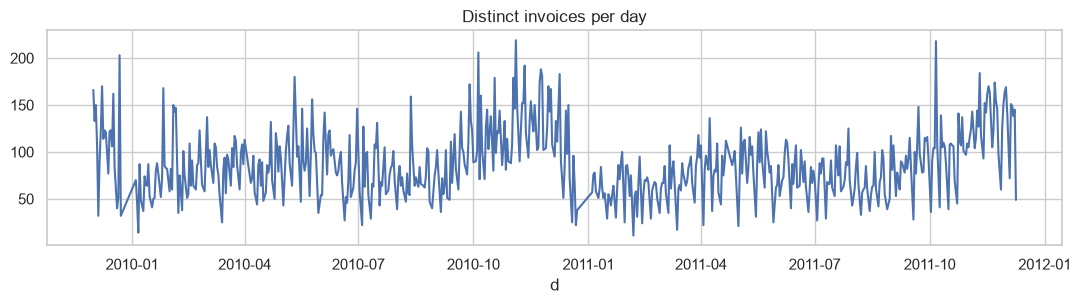

In [3]:
raw = raw.copy()
raw["Invoice"] = raw["Invoice"].astype(str)
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
print("Missing %:\n", (100 * raw.isna().mean()).round(2))
print("Cancels:", raw["Invoice"].str.startswith("C").sum())
print("Date range:", raw["InvoiceDate"].min(), "→", raw["InvoiceDate"].max())

daily = raw.dropna(subset=["InvoiceDate"]).assign(d=lambda x: x["InvoiceDate"].dt.date)
daily = daily.groupby("d")["Invoice"].nunique()
fig, ax = plt.subplots(figsize=(11, 3.2))
daily.plot(ax=ax)
ax.set_title("Distinct invoices per day")
plt.tight_layout()
plt.show()

## 3. RFM engineering + production preprocessing

**Research-backed steps** used here:

- Aggregate RFM at customer grain (standard CRM practice)
- **Winsorize** at 1%/99% so KMeans/GMM are not dominated by extreme spenders
- **log1p** on Frequency & Monetary (heavy right skew in retail)
- **RobustScaler** (median/IQR) — more stable than StandardScaler with residual outliers
- Optional **RFM quantile scores** for interpretability (classic 1–5 scores)

Raw rows: 1,067,371 | Cleaned: 805,549 | Customers: 5,878


RFM shape: (5878, 4)


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


Skew raw:
 Recency       0.887198
Frequency    12.639951
Monetary     25.314235
dtype: float64


,R_score,F_score,M_score,RFM_score
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,3.000000,3.000000,3.000000,9.000000
std,1.414454,1.414454,1.414454,3.642386
min,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,2.000000,6.000000
50%,3.000000,3.000000,3.000000,9.000000
75%,4.000000,4.000000,4.000000,12.000000
max,5.000000,5.000000,5.000000,15.000000


Preprocess meta: {'scaler': 'robust', 'log_cols': ['Frequency', 'Monetary']}
Winsor bounds:
              lower       upper
Recency     0.0000    725.0000
Frequency   1.0000     46.0000
Monetary   46.8465  29730.4202
X shape: (5878, 3)


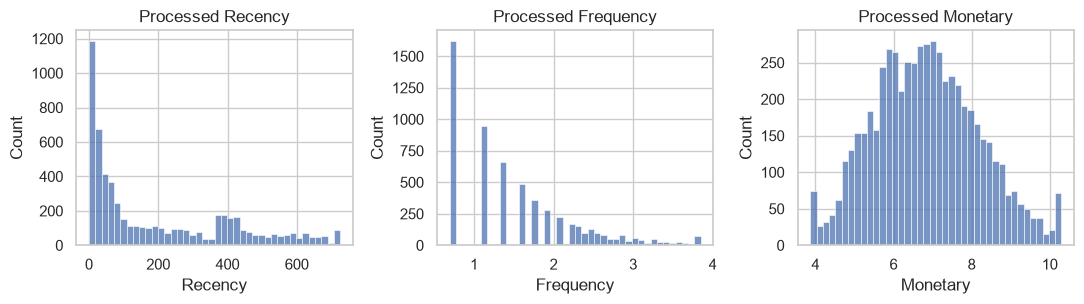

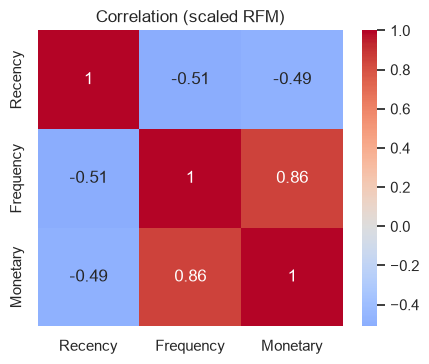

In [4]:
tx = clean_transactions(
    raw,
    invoice_col="Invoice",
    customer_col="Customer ID",
    qty_col="Quantity",
    price_col="Price",
    date_col="InvoiceDate",
)
print(f"Raw rows: {len(raw):,} | Cleaned: {len(tx):,} | Customers: {tx['Customer ID'].nunique():,}")

rfm = build_rfm(
    tx,
    customer_col="Customer ID",
    invoice_col="Invoice",
    date_col="InvoiceDate",
)
rfm["Customer ID"] = rfm["Customer ID"].astype(int)
print("RFM shape:", rfm.shape)
display(rfm[["Recency", "Frequency", "Monetary"]].describe())
print("Skew raw:\n", rfm[["Recency", "Frequency", "Monetary"]].skew())

rfm_scored = rfm_quantile_scores(rfm, n_bins=5)
display(rfm_scored[["R_score", "F_score", "M_score", "RFM_score"]].describe())

feat_cols = ["Recency", "Frequency", "Monetary"]
X, work, scaler, meta = prepare_matrix(
    rfm,
    feat_cols,
    winsorize=True,
    log_cols=["Frequency", "Monetary"],
    scaler="robust",
    lower_q=0.01,
    upper_q=0.99,
)
print("Preprocess meta:", {k: meta[k] for k in ["scaler", "log_cols"]})
print("Winsor bounds:\n", meta["bounds"])
print("X shape:", X.shape)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, c in zip(axes, feat_cols):
    sns.histplot(work[c], bins=40, ax=ax)
    ax.set_title(f"Processed {c}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(pd.DataFrame(X, columns=feat_cols).corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation (scaled RFM)")
plt.tight_layout()
plt.show()

## 4. Algorithm survey (fixed k=4 shortlist)

Shortlist **families** quickly, then deep-tune k per family. Includes **GMM**, which
often fits RFM better than spherical KMeans when clusters differ in variance.

In [5]:
survey = survey_algorithms(
    X,
    models=["kmeans", "minibatch_kmeans", "hclust", "birch", "gmm"],
    n_clusters=4,
    random_state=SEED,
)
print("=== Fixed-k=4 survey ===")
display(survey)
best_two = top_two_families(survey)
print("Best 2 families for deep tune:", best_two)

=== Fixed-k=4 survey ===


,model,n_clusters,error,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,production_score
0,kmeans,4,,0,0.0,33.208574,18.730861,0.358785,0.906805,6004.562439,0.496377
1,minibatch_kmeans,4,,0,0.0,34.263355,19.887717,0.358322,0.910296,5968.312989,0.494548
2,hclust,4,,0,0.0,35.692412,12.759442,0.312470,0.912886,4730.237178,0.411346
3,birch,4,,0,0.0,45.406601,15.175230,0.310476,1.061015,4143.978640,0.379914
4,gmm,4,,0,0.0,27.781558,19.122150,0.099795,2.455375,2132.721857,-0.002654


Best 2 families for deep tune: ['kmeans', 'minibatch_kmeans']


## 5. Deep k-sweep + stability for the best 2 families

For each family we sweep `k = 2..8` and compute:

- Silhouette, Davies–Bouldin, Calinski–Harabasz  
- **Bootstrap ARI stability** (subsample 70%, 6 boots)  
- **production_score** (geometry + balance + stability + slight preference for 3–5 segments)


=== Sweep kmeans ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
0,kmeans,2,0,0.0,53.980946,46.019054,0.426774,0.870072,6289.789663,0.968350,3353.252902,NaN,NaN,0.662064
1,kmeans,3,0,0.0,39.673358,29.959170,0.390058,0.910988,6178.002096,0.955425,2237.289192,NaN,NaN,0.647170
3,kmeans,5,0,0.0,28.615175,15.073154,0.372088,0.860644,6044.402428,0.948858,1356.851644,NaN,NaN,0.628431
2,kmeans,4,0,0.0,33.208574,18.730861,0.358785,0.906805,6004.562439,0.947055,1707.207120,NaN,NaN,0.610024
4,kmeans,6,0,0.0,22.201429,9.305886,0.354952,0.875411,6001.845859,0.958148,1136.188655,NaN,NaN,0.579953
5,kmeans,7,0,0.0,22.065328,9.169786,0.338113,0.925208,5671.229702,0.921461,1021.611049,NaN,NaN,0.544808
6,kmeans,8,0,0.0,17.574005,7.349439,0.309448,0.984728,5462.090622,0.887578,924.024854,NaN,NaN,0.501042


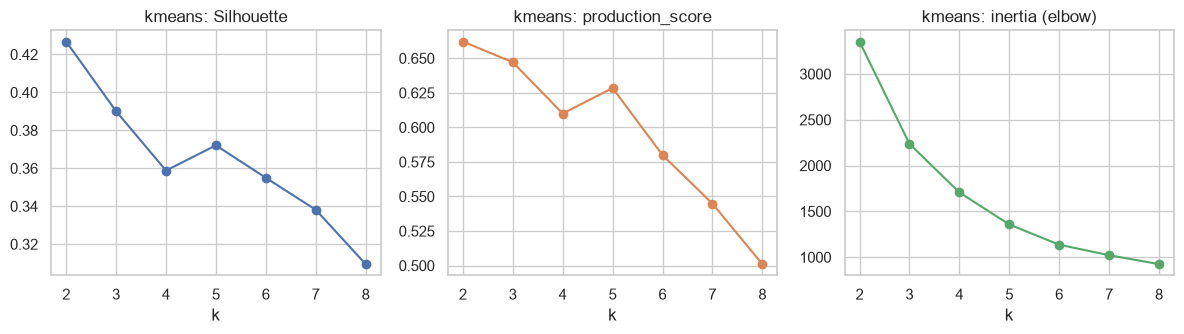


=== Sweep minibatch_kmeans ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
0,minibatch_kmeans,2,0,0.0,53.504593,46.495407,0.426732,0.871522,6288.416961,0.945822,3353.252902,NaN,NaN,0.659162
1,minibatch_kmeans,3,0,0.0,39.077918,30.248384,0.390592,0.910193,6177.326118,0.769773,2237.289192,NaN,NaN,0.625469
2,minibatch_kmeans,4,0,0.0,34.263355,19.887717,0.358322,0.910296,5968.312989,0.682067,1707.207120,NaN,NaN,0.576396
4,minibatch_kmeans,6,0,0.0,27.560395,9.612113,0.347284,0.946471,5441.404603,0.494340,1136.188655,NaN,NaN,0.494130
3,minibatch_kmeans,5,0,0.0,26.148350,12.742429,0.321796,0.996233,5360.451738,0.465703,1356.851644,NaN,NaN,0.488795
5,minibatch_kmeans,7,0,0.0,19.360327,5.290915,0.323386,0.951558,5537.906387,0.586490,1021.611049,NaN,NaN,0.483777
6,minibatch_kmeans,8,0,0.0,17.982307,5.699217,0.314540,0.969602,5442.217903,0.684461,924.024854,NaN,NaN,0.482374


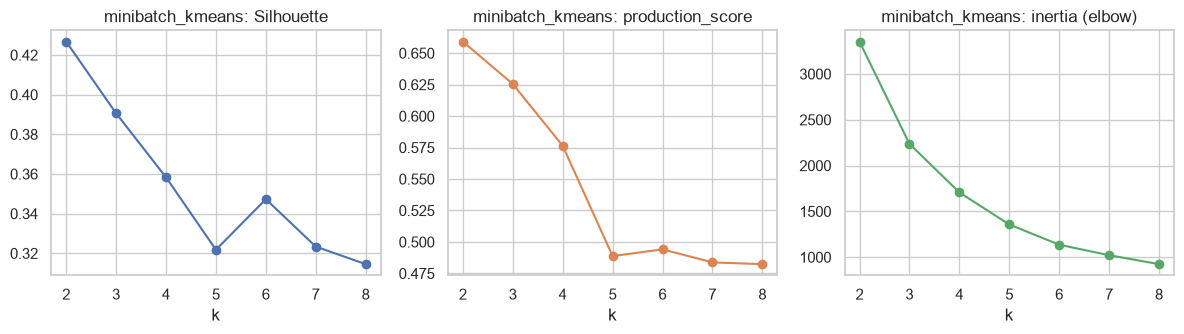


=== Global ranking (top 10) ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
0,kmeans,2,0,0.0,53.980946,46.019054,0.426774,0.870072,6289.789663,0.968350,3353.252902,NaN,NaN,0.662064
7,minibatch_kmeans,2,0,0.0,53.504593,46.495407,0.426732,0.871522,6288.416961,0.945822,3353.252902,NaN,NaN,0.659162
1,kmeans,3,0,0.0,39.673358,29.959170,0.390058,0.910988,6178.002096,0.955425,2237.289192,NaN,NaN,0.647170
3,kmeans,5,0,0.0,28.615175,15.073154,0.372088,0.860644,6044.402428,0.948858,1356.851644,NaN,NaN,0.628431
8,minibatch_kmeans,3,0,0.0,39.077918,30.248384,0.390592,0.910193,6177.326118,0.769773,2237.289192,NaN,NaN,0.625469
2,kmeans,4,0,0.0,33.208574,18.730861,0.358785,0.906805,6004.562439,0.947055,1707.207120,NaN,NaN,0.610024
4,kmeans,6,0,0.0,22.201429,9.305886,0.354952,0.875411,6001.845859,0.958148,1136.188655,NaN,NaN,0.579953
9,minibatch_kmeans,4,0,0.0,34.263355,19.887717,0.358322,0.910296,5968.312989,0.682067,1707.207120,NaN,NaN,0.576396
5,kmeans,7,0,0.0,22.065328,9.169786,0.338113,0.925208,5671.229702,0.921461,1021.611049,NaN,NaN,0.544808
6,kmeans,8,0,0.0,17.574005,7.349439,0.309448,0.984728,5462.090622,0.887578,924.024854,NaN,NaN,0.501042


Configs to implement properly:
  kmeans k=2 | Sil=0.4268 | DB=0.870 | CH=6289.8 | stab=0.968 | prod=0.6621
  minibatch_kmeans k=2 | Sil=0.4267 | DB=0.872 | CH=6288.4 | stab=0.946 | prod=0.6592


In [6]:
sweeps = {}
for fam in best_two:
    print(f"\n=== Sweep {fam} ===")
    sw = sweep_k(fam, X, ks=range(2, 9), random_state=SEED, compute_stability=True)
    sweeps[fam] = sw
    display(sw.sort_values("production_score", ascending=False))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].plot(sw["n_clusters"], sw["silhouette"], "o-", color="C0")
    axes[0].set_title(f"{fam}: Silhouette")
    axes[1].plot(sw["n_clusters"], sw["production_score"], "o-", color="C1")
    axes[1].set_title(f"{fam}: production_score")
    if sw["inertia"].notna().any():
        axes[2].plot(sw["n_clusters"], sw["inertia"], "o-", color="C2")
        axes[2].set_title(f"{fam}: inertia (elbow)")
    else:
        axes[2].plot(sw["n_clusters"], sw["stability_ari"], "o-", color="C2")
        axes[2].set_title(f"{fam}: stability ARI")
    for ax in axes:
        ax.set_xlabel("k")
    plt.tight_layout()
    plt.show()

# Global best + second-best distinct families for side-by-side delivery
model_a, k_a, best_row, ranking = select_best_config(sweeps)
print("\n=== Global ranking (top 10) ===")
display(ranking.head(10))

# Ensure two configs for comparison: best overall + best of the other family
configs = [(model_a, k_a, best_row)]
other = [m for m in best_two if m != model_a]
if other:
    sw_o = sweeps[other[0]].sort_values("production_score", ascending=False).iloc[0]
    configs.append((other[0], int(sw_o["n_clusters"]), sw_o))
else:
    # second row of ranking if same family
    if len(ranking) > 1:
        r2 = ranking.iloc[1]
        configs.append((str(r2["model"]), int(r2["n_clusters"]), r2))

print("Configs to implement properly:")
for m, k, r in configs:
    print(
        f"  {m} k={k} | Sil={r['silhouette']:.4f} | DB={r['davies_bouldin']:.3f} | "
        f"CH={r['calinski_harabasz']:.1f} | stab={r.get('stability_ari', np.nan):.3f} | "
        f"prod={r['production_score']:.4f}"
    )

## 6. Final models — fit, PCA, profiles


### kmeans k=2
{'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 53.980945899965974, 'min_cluster_pct': 46.019054100034026, 'silhouette': 0.42677435976080486, 'davies_bouldin': 0.8700724832373724, 'calinski_harabasz': 6289.789662643852, 'production_score': 0.6620643086256421}


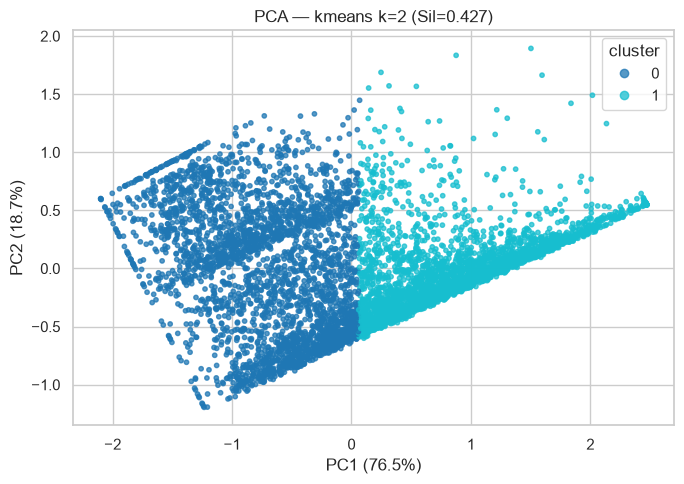

,cluster,n,mean_R,mean_F,mean_M,total_M,median_M,pct_n,pct_M
1,1,2705,70.401109,11.503142,5989.845898,1.620253e+07,2533.94,46.019054,91.315681
0,0,3173,311.098645,1.844627,485.627489,1.540896e+06,373.94,53.980946,8.684319


Heuristic labels: {1: 'Champions / Loyal high-value', 0: 'At-risk / Lapsed'}



### minibatch_kmeans k=2
{'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 53.50459339911534, 'min_cluster_pct': 46.49540660088466, 'silhouette': 0.426732214774035, 'davies_bouldin': 0.8715219225581934, 'calinski_harabasz': 6288.416960667065, 'production_score': 0.6591615585418052}


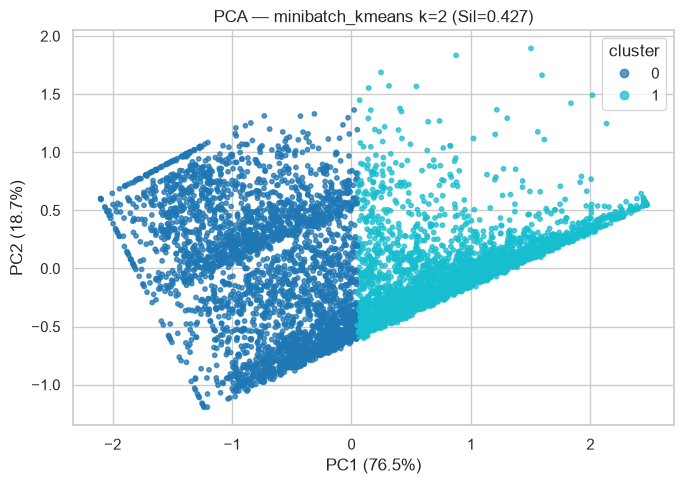

,cluster,n,mean_R,mean_F,mean_M,total_M,median_M,pct_n,pct_M
1,1,2733,71.538602,11.422247,5943.244791,1.624289e+07,2495.87,46.495407,91.543116
0,0,3145,312.253100,1.828935,477.119607,1.500541e+06,371.20,53.504593,8.456884


Heuristic labels: {1: 'Champions / Loyal high-value', 0: 'At-risk / Lapsed'}


In [7]:
results = {}
for model_name, k, row in configs:
    labels = labels_for_config(model_name, X, k, random_state=SEED)
    m = internal_metrics(X, labels)
    m["production_score"] = production_score({**m, "stability_ari": row.get("stability_ari", np.nan)})
    print(f"\n### {model_name} k={k}")
    print(m)

    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=10, alpha=0.75)
    ax.set_title(f"PCA — {model_name} k={k} (Sil={m['silhouette']:.3f})")
    ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
    ax.legend(*sc.legend_elements(), title="cluster")
    plt.tight_layout()
    plt.show()

    tmp = rfm.copy()
    tmp["cluster"] = labels
    prof = (
        tmp.groupby("cluster")
        .agg(
            n=("Customer ID", "count"),
            mean_R=("Recency", "mean"),
            mean_F=("Frequency", "mean"),
            mean_M=("Monetary", "mean"),
            total_M=("Monetary", "sum"),
            median_M=("Monetary", "median"),
        )
        .reset_index()
    )
    prof["pct_n"] = 100 * prof["n"] / prof["n"].sum()
    prof["pct_M"] = 100 * prof["total_M"] / prof["total_M"].sum()
    prof = prof.sort_values("mean_M", ascending=False)
    display(prof)

    # name segments heuristically
    names = {}
    for _, pr in prof.iterrows():
        cl = int(pr["cluster"])
        if pr["mean_R"] <= prof["mean_R"].median() and pr["mean_M"] >= prof["mean_M"].median():
            names[cl] = "Champions / Loyal high-value"
        elif pr["mean_R"] > prof["mean_R"].quantile(0.66):
            names[cl] = "At-risk / Lapsed"
        elif pr["mean_F"] <= prof["mean_F"].median():
            names[cl] = "Promising / Low frequency"
        else:
            names[cl] = "Core / Steady"
    print("Heuristic labels:", names)

    results[f"{model_name}_k{k}"] = {
        "model": model_name,
        "k": k,
        "labels": labels,
        "metrics": m,
        "profile": prof,
        "names": names,
        "row": row,
    }

## 7. Side-by-side comparison & preferred production model

In [8]:
cmp = []
for key, res in results.items():
    m = res["metrics"]
    cmp.append(
        {
            "config": key,
            "model": res["model"],
            "k": res["k"],
            "silhouette": m["silhouette"],
            "davies_bouldin": m["davies_bouldin"],
            "calinski_harabasz": m["calinski_harabasz"],
            "largest_pct": m["largest_cluster_pct"],
            "min_pct": m["min_cluster_pct"],
            "stability_ari": res["row"].get("stability_ari", np.nan),
            "production_score": m["production_score"],
        }
    )
cmp_df = pd.DataFrame(cmp).sort_values("production_score", ascending=False)
display(cmp_df)
preferred_key = cmp_df.iloc[0]["config"]
pref = results[preferred_key]
print("PREFERRED PRODUCTION CONFIG:", preferred_key)

,config,model,k,silhouette,davies_bouldin,calinski_harabasz,largest_pct,min_pct,stability_ari,production_score
0,kmeans_k2,kmeans,2,0.426774,0.870072,6289.789663,53.980946,46.019054,0.968350,0.662064
1,minibatch_kmeans_k2,minibatch_kmeans,2,0.426732,0.871522,6288.416961,53.504593,46.495407,0.945822,0.659162


PREFERRED PRODUCTION CONFIG: kmeans_k2


## 8. Manager brief (preferred model)

In [9]:
prof = pref["profile"]
print("MANAGER BRIEF — Online Retail II (production pipeline)")
print("=" * 64)
print(
    f"Model: {pref['model']} with k={pref['k']} | "
    f"Silhouette={pref['metrics']['silhouette']:.3f} | "
    f"DB={pref['metrics']['davies_bouldin']:.3f} | "
    f"CH={pref['metrics']['calinski_harabasz']:.1f} | "
    f"stability_ARI={pref['row'].get('stability_ari', float('nan')):.3f}"
)
print(f"Customers segmented: {len(rfm):,}")
print()
actions = {
    "Champions / Loyal high-value": "VIP retention, early access, dedicated service — protect revenue concentration.",
    "At-risk / Lapsed": "Win-back sequence with modest incentive timed to recency decay.",
    "Promising / Low frequency": "Cross-sell / frequency drivers (bundles, loyalty stamps).",
    "Core / Steady": "Efficient lifecycle automation; test moderate upsell.",
}
for _, pr in prof.iterrows():
    cl = int(pr["cluster"])
    name = pref["names"].get(cl, f"Segment {cl}")
    act = actions.get(name, "Define a test-and-learn offer for this profile.")
    print(
        f"[{name}] cluster={cl}: n={int(pr['n'])} ({pr['pct_n']:.1f}% cust, {pr['pct_M']:.1f}% revenue) | "
        f"R={pr['mean_R']:.0f}d F={pr['mean_F']:.1f} M=£{pr['mean_M']:.0f} (median £{pr['median_M']:.0f})"
    )
    print(f"  → {act}")

MANAGER BRIEF — Online Retail II (production pipeline)
Model: kmeans with k=2 | Silhouette=0.427 | DB=0.870 | CH=6289.8 | stability_ARI=0.968
Customers segmented: 5,878

[Champions / Loyal high-value] cluster=1: n=2705 (46.0% cust, 91.3% revenue) | R=70d F=11.5 M=£5990 (median £2534)
  → VIP retention, early access, dedicated service — protect revenue concentration.
[At-risk / Lapsed] cluster=0: n=3173 (54.0% cust, 8.7% revenue) | R=311d F=1.8 M=£486 (median £374)
  → Win-back sequence with modest incentive timed to recency decay.


## 9. Production notes & limitations

- **Preprocessing** (winsorize + log + robust scale) is part of the model artifact — reapply the same bounds at scoring time.
- **Stability ARI** is a subsample self-consistency check, not a guarantee of future-period stability.
- Re-fit periodically (e.g. monthly) as the customer base drifts.
- No supervised accuracy exists for segments; validate with **campaign A/B tests**.